In [2]:
import importlib
import utils
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity

_ = importlib.reload(utils)
# import yfinance as yf


In [ ]:
df = utils.get_revisions_data("X (social network)")
df.to_csv("x_revisions_with_text.csv")

In [ ]:
# tsla = yf.Ticker("TSLA")

# history = tsla.history(period="max", interval="1d")

# history = history.reset_index()

# tsla_df = history[['Date', 'Close', 'Volume']]

# tsla_df.to_csv("tesla_stock_time_series.csv", index=False)

# print(f"Дані збережено! Кількість записів: {len(tsla_df)}")
# print(tsla_df.head())

Дані збережено! Кількість записів: 3958
                       Date     Close     Volume
0 2010-06-29 00:00:00-04:00  1.592667  281494500
1 2010-06-30 00:00:00-04:00  1.588667  257806500
2 2010-07-01 00:00:00-04:00  1.464000  123282000
3 2010-07-02 00:00:00-04:00  1.280000   77097000
4 2010-07-06 00:00:00-04:00  1.074000  103003500


In [ ]:
# Run this cell to combine all 5 CSV files into one master file "all_revisions.csv"
files_map = {
    "Tesla": "tesla_revisions_with_text.csv",
    "SpaceX": "spacex_revisions_with_text.csv",
    "Elon Musk": "elon_musk_revisions_with_text.csv",
    "X": "x_revisions_with_text.csv",
    "Twitter": "twitter_revisions_with_text.csv"
}

all_dfs = []

for entity, filename in files_map.items():
    print(f"Обробка: {entity}...")
    
    df = pd.read_csv(filename)
    
    df['entity'] = entity
    
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    if 'intro_text' in df.columns:
        df['intro_text'] = df['intro_text'].fillna("")
        df['nwords_intro'] = df['intro_text'].str.split().str.len()
    
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df = final_df.sort_values(by=['entity', 'timestamp'])

final_df.to_csv("all_revisions.csv", index=False)

print("\n✅ Усі 5 файлів успішно об'єднано!")
print(f"Разом рядків: {len(final_df)}")
print(f"Збережено у: all_revisions.csv")

Обробка: Tesla...
Обробка: SpaceX...
Обробка: Elon Musk...
Обробка: X...
Обробка: Twitter...

✅ Усі 5 файлів успішно об'єднано!
Разом рядків: 38884
Збережено у: all_entities_revisions_master.csv


In [42]:
df = pd.read_csv("all_revisions.csv")

In [43]:
df["intro_text"] = df["intro_text"].fillna("")
wtext = df[df["intro_text"] != ""]
wtext["timestamp"] = pd.to_datetime(wtext["timestamp"])

C:\Users\DL5400\AppData\Local\Temp\ipykernel_26960\4214858814.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wtext["timestamp"] = pd.to_datetime(wtext["timestamp"])


In [44]:
wtext = wtext.sort_values(by="timestamp", ascending=True)

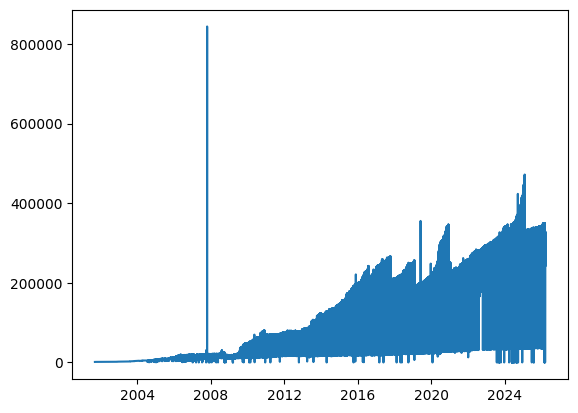

In [45]:
plt.plot(wtext["timestamp"], wtext["size"])

In [46]:
wtext["nwords_intro"] = wtext["intro_text"].apply(lambda x: len(x.split(" ")))

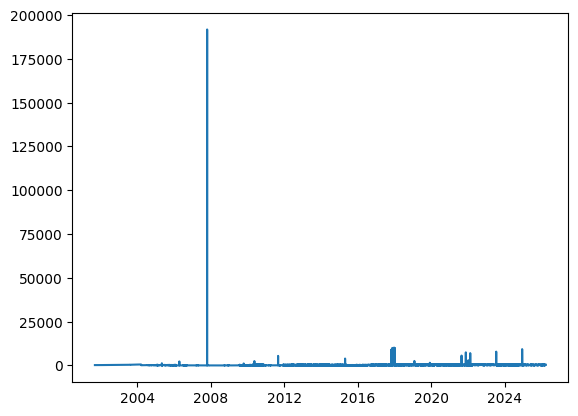

In [47]:
plt.plot(wtext["timestamp"], wtext["nwords_intro"])

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
corpus = wtext["intro_text"]
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()
bow_matrix = X.toarray()

bow_df = pd.DataFrame(bow_matrix, columns=feature_names, index=corpus)
print("Vocabulary (Unique Words):")
print(feature_names)
# print("\nBag of Words Matrix (Word Frequencies):")
# print(df)

bow_df.to_csv("bow_df.csv")


Vocabulary (Unique Words):
['00' '000' '000118141217000002' ... '艾隆' '馬斯克' 'ꭓx']


In [49]:
cos_sim = cosine_similarity(X[1:], X[:-1]).diagonal()
cos_sim = np.insert(cos_sim, 0, np.nan)


In [50]:
wtext["cosine"]=cos_sim
wtext.head()

,Unnamed: 0,revid,parentid,timestamp,user,temp,comment,size,sha1,flags,intro_text,minor,entity,nwords_intro,cosine
36159,2724,1286858074,0,2001-09-09 16:48:10+00:00,AxelBoldt,False,NaN,1362,cdf3b0bd4be830eb0468f2b4b0bd9dfa517059df,NaN,1. a letter of the alphabet/ks/ was in Ancient...,False,X,223,NaN
36160,2723,297808,0,2001-10-03 02:11:30+00:00,61.9.128.xxx,False,NaN,1482,8b10c95478b26ff85b6684326b80a20c6b749c06,NaN,1. a letter of the alphabet\r\r/ks/ was in Anc...,False,X,235,0.986754
36161,2722,297809,297808,2002-01-18 15:54:38+00:00,165.121.112.xxx,False,NaN,1496,86b4c437d491f6c6a36100b36c9e0a9bd4feed9a,NaN,1. a letter of the alphabet\r\r/ks/ was in Anc...,False,X,238,1.000000
36162,2721,65483,297809,2002-02-25 15:43:11+00:00,Conversion script,False,NaN,1581,3d124f745dd0bd9e4bd96eb30c840cb6471afc0b,NaN,1. a letter of the alphabet\r\r/ks/ was in Anc...,True,X,245,0.990275
36163,2720,65486,65483,2002-04-21 11:47:33+00:00,Damian Yerrick,False,NaN,1601,33a877eccaf092d1a885faa3d08ad5d6540fc996,NaN,X is a letter of the Latin alphabet.\r\r/ks/ w...,False,X,256,0.985002


In [51]:
wtext["year"] = wtext["timestamp"].dt.year

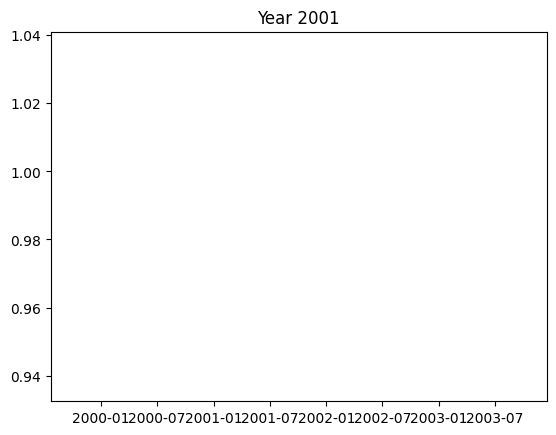

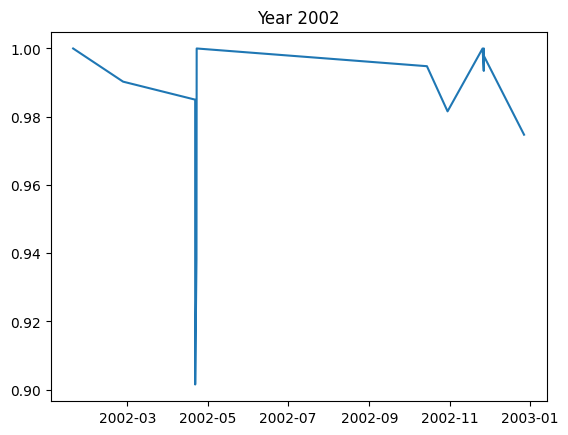

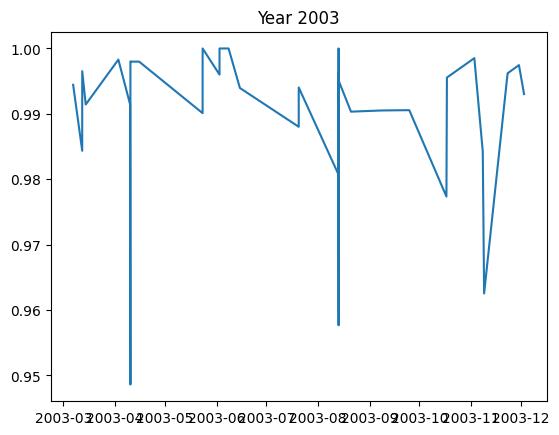

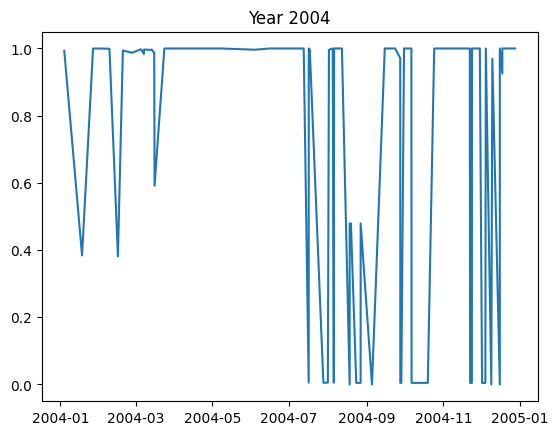

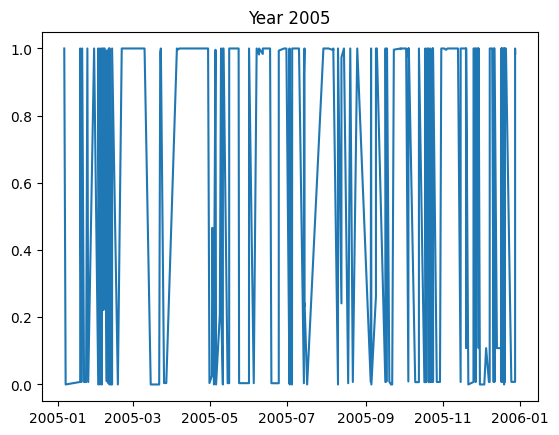

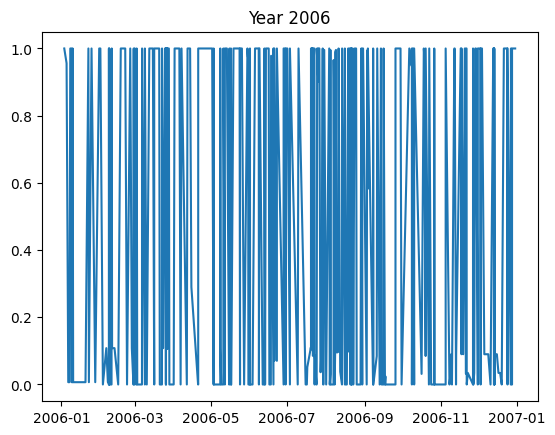

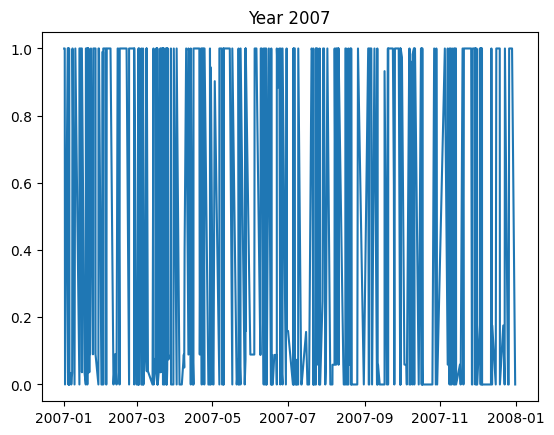

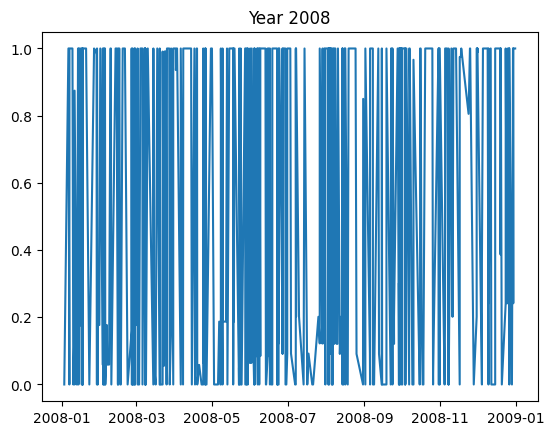

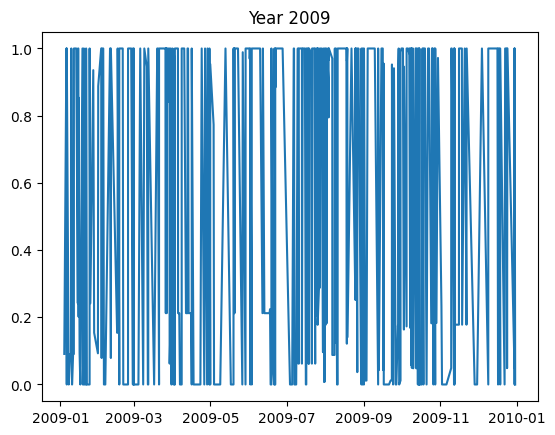

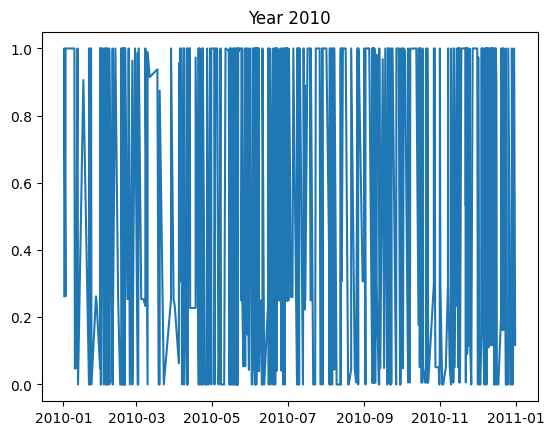

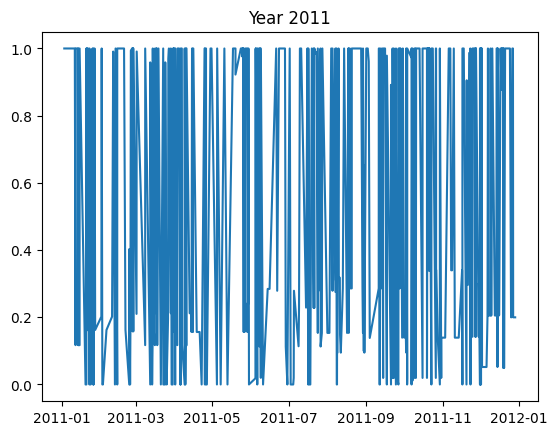

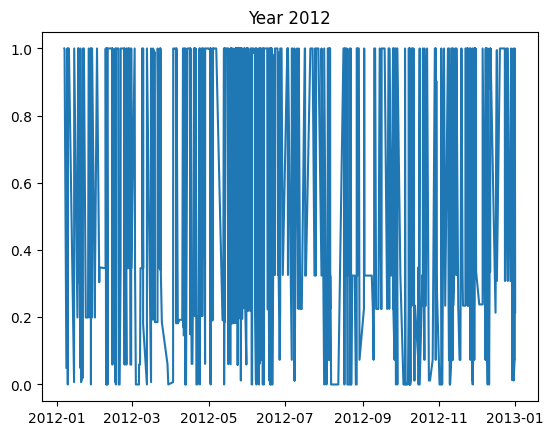

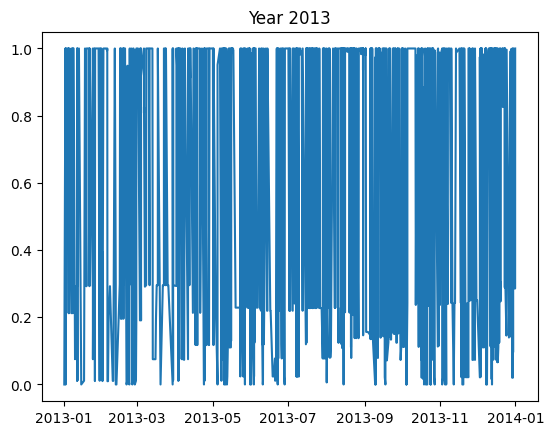

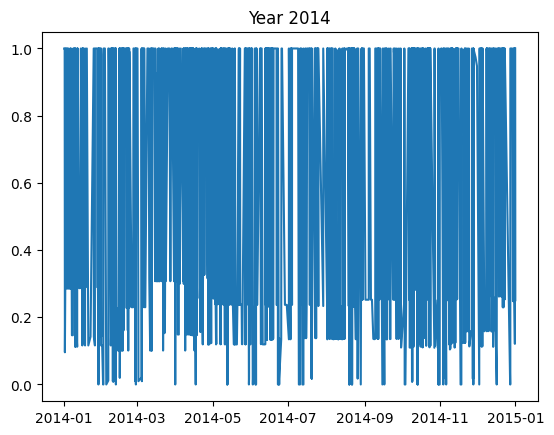

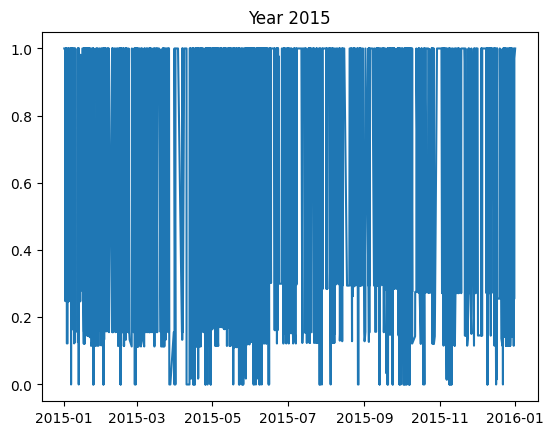

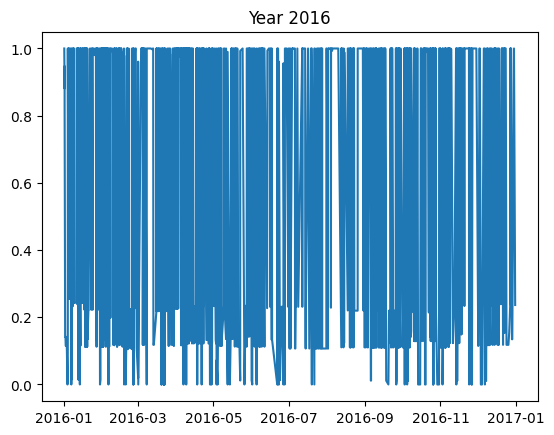

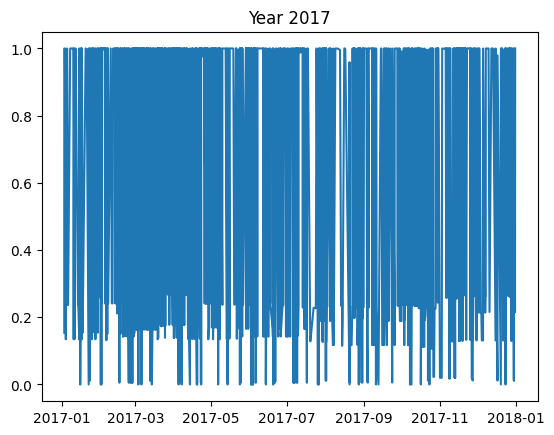

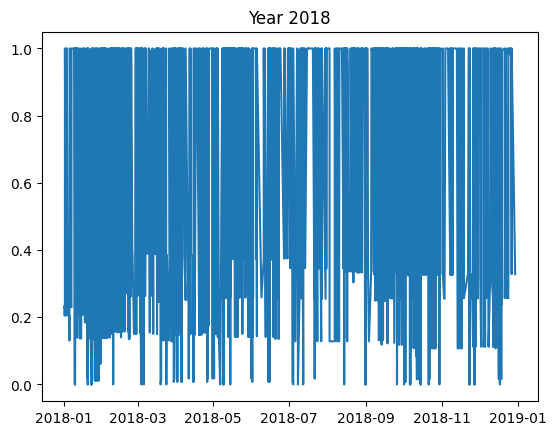

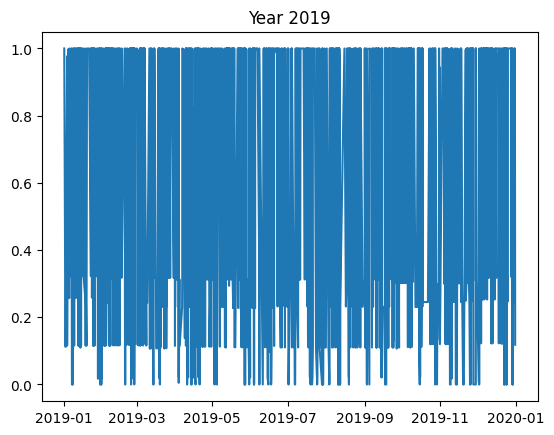

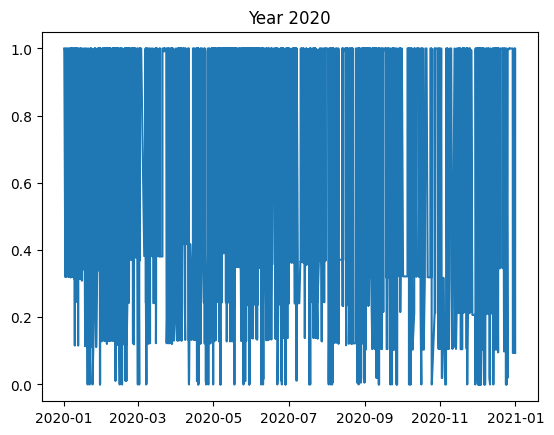

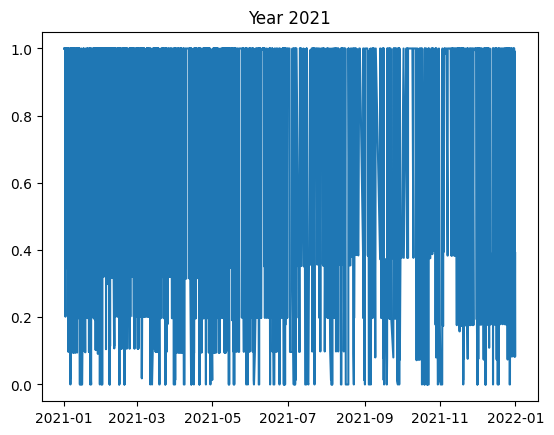

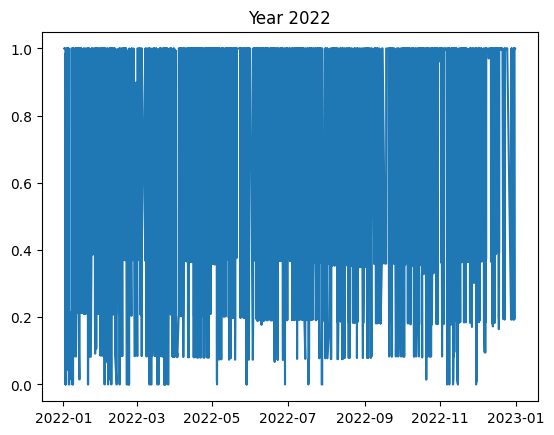

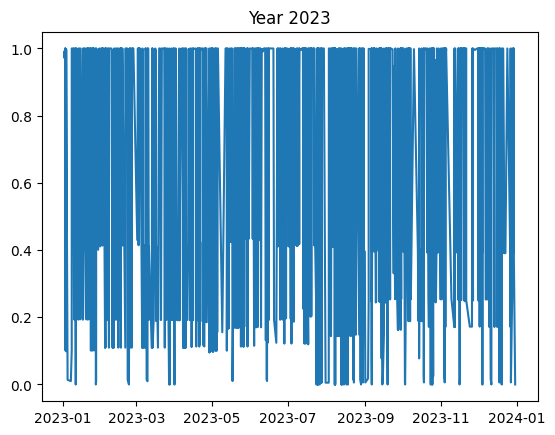

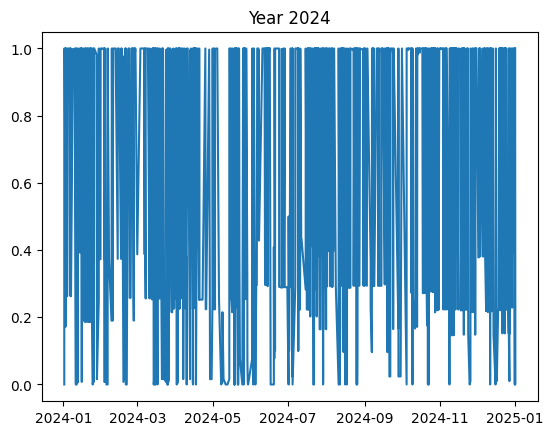

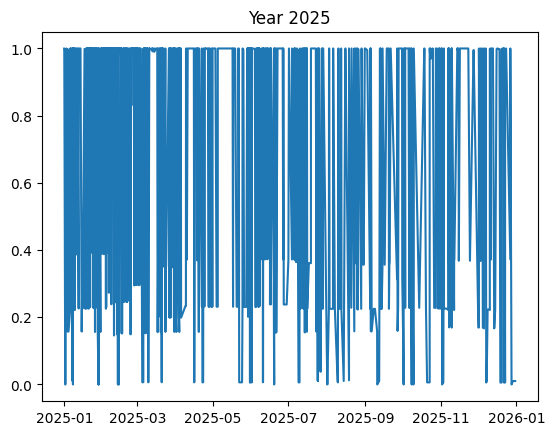

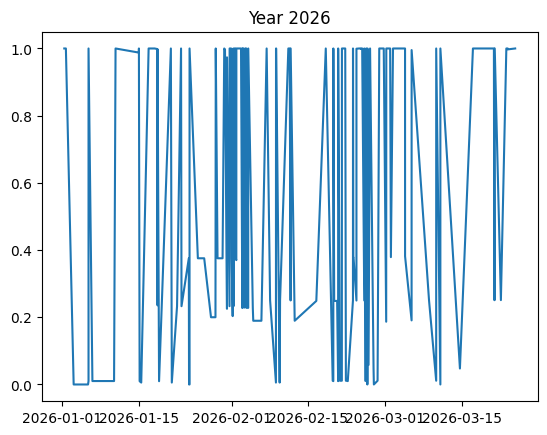

In [52]:
for year, group in wtext.groupby("year"):
    plt.figure()
    plt.plot(group["timestamp"], group["cosine"])
    plt.title(f"Year {year}")
    plt.show()

In [53]:

cosine_baseline = cosine_similarity(X, X[0]).flatten()


In [54]:
wtext["cosine_baseline"] = cosine_baseline

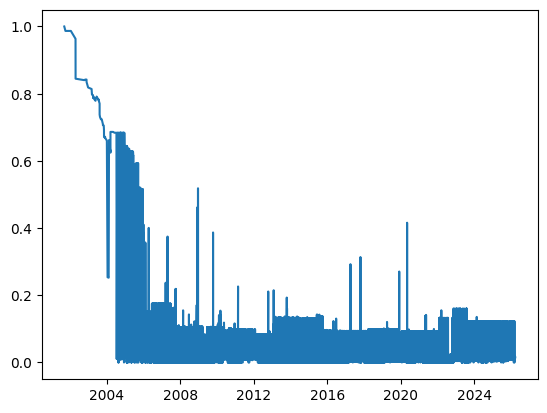

In [55]:
plt.plot(wtext["timestamp"], wtext["cosine_baseline"])

In [56]:
wtext_cleaned = wtext[wtext["cosine_baseline"] > 0.2]

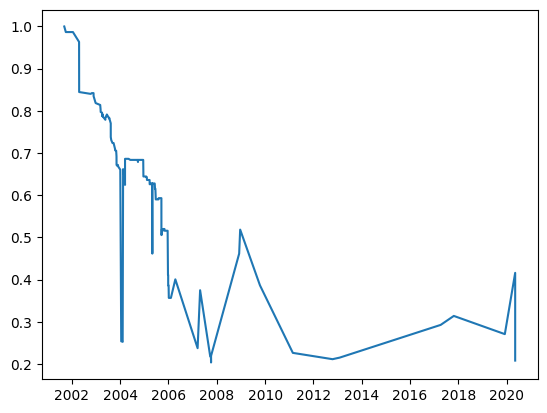

In [57]:
plt.plot(wtext_cleaned["timestamp"], wtext_cleaned["cosine_baseline"])